In [40]:
# imports

import pandas as pd
import numpy as np

In [41]:
# reading the csv

df = pd.read_csv("./data/ex2.csv")
df.head()

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,CollegeCityID,CollegeCityTier,CollegeState,GraduationYear,English,Logical,Quant,Domain,ComputerProgramming,Salary
0,604399,f,22-10-1990,87.80,cbse,2009,84.00,cbse,6920,1,...,6920,1,Delhi,2013,650,665,810,0.694479,485,445000.0
1,988334,m,15-05-1990,57.00,cbse,2010,64.50,cbse,6624,2,...,6624,0,Uttar Pradesh,2014,440,435,210,0.342315,365,NaN
2,301647,m,21-08-1989,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,9084,0,Maharashtra,2011,485,475,505,0.824666,-1,255000.0
3,582313,m,04-05-1991,84.30,cbse,2009,86.00,cbse,8195,1,...,8195,1,Delhi,2013,675,620,635,0.990009,655,420000.0
4,339001,f,30-10-1990,82.00,cbse,2008,75.00,cbse,4889,2,...,4889,1,Tamil Nadu,2012,575,495,365,0.278457,315,200000.0


In [42]:
# checking for duplicated rows and accumulating the sum

df.duplicated().sum()

np.int64(0)

In [43]:
# checking for null values

df.isnull().sum()

ID                       0
Gender                   0
DOB                      0
10percentage           249
10board                  0
12graduation             0
12percentage             0
12board                  0
CollegeID                0
CollegeTier              0
Degree                   0
Specialization           0
collegeGPA             266
CollegeCityID            0
CollegeCityTier          0
CollegeState             0
GraduationYear           0
English                  0
Logical                  0
Quant                    0
Domain                   0
ComputerProgramming      0
Salary                 290
dtype: int64

In [44]:
# checking for sentinel -1 values in the measurement columns (a score can't be negative)

measure_cols = ['10percentage', '12percentage', 'collegeGPA', 'English', 'Logical',
                 'Quant', 'Domain', 'ComputerProgramming', 'Salary']

for col in measure_cols:
    print(f"{col} : {(df[col] < 0).sum()}")

10percentage : 0
12percentage : 0
collegeGPA : 0
English : 0
Logical : 0
Quant : 0
Domain : 179
ComputerProgramming : 650
Salary : 0


In [45]:
# converting sentinel -1 values to real NaN

df.loc[df['ComputerProgramming'] < 0, 'ComputerProgramming'] = np.nan
df.loc[df['Domain'] < 0, 'Domain'] = np.nan

df.isnull().sum().loc[lambda s: s > 0]

10percentage           249
collegeGPA             266
Domain                 179
ComputerProgramming    650
Salary                 290
dtype: int64

In [46]:
# checking skew to decide between mean and median for filling

cols_with_na = df.columns[df.isnull().sum() > 0]

for col in cols_with_na:
    print(f"{col} : {df[col].skew():.3f}")

10percentage : -0.581
collegeGPA : -1.336
Domain : -0.353
ComputerProgramming : -0.039
Salary : 7.043


In [47]:
# filling missing values: median for skewed columns (|skew| > 0.5), mean for roughly symmetric ones

df['10percentage'] = df['10percentage'].fillna(df['10percentage'].median())
df['collegeGPA'] = df['collegeGPA'].fillna(df['collegeGPA'].median())
df['Domain'] = df['Domain'].fillna(df['Domain'].mean())
df['ComputerProgramming'] = df['ComputerProgramming'].fillna(df['ComputerProgramming'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

df.isnull().sum().sum()

np.int64(0)

In [48]:
# checking for outliers (IQR method) and removing rows that fall outside the fences

def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

mask = pd.Series(True, index=df.index)
for col in measure_cols:
    lower, upper = iqr_bounds(df[col])
    in_range = df[col].between(lower, upper)
    print(f"{col} : {(~in_range).sum()} outliers (bounds {lower:.2f} to {upper:.2f})")
    mask &= in_range

print(f"\nRows before: {len(df)}")
df = df[mask].reset_index(drop=True)
print(f"Rows after:  {len(df)}")

10percentage : 35 outliers (bounds 52.50 to 104.50)
12percentage : 1 outliers (bounds 41.10 to 107.50)
collegeGPA : 53 outliers (bounds 53.50 to 89.50)
English : 12 outliers (bounds 207.50 to 787.50)
Logical : 15 outliers (bounds 255.62 to 750.62)
Quant : 22 outliers (bounds 182.50 to 842.50)
Domain : 0 outliers (bounds -0.31 to 1.52)
ComputerProgramming : 145 outliers (bounds 270.00 to 630.00)
Salary : 124 outliers (bounds -30625.00 to 584375.00)

Rows before: 2998
Rows after:  2629


# **Charts**

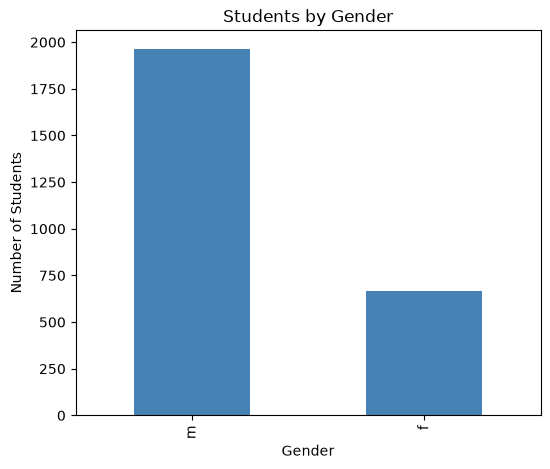

In [49]:
# 1. Bar chart : count of students by Gender

df['Gender'].value_counts().plot(kind='bar', color='steelblue', figsize=(6, 5),
                                  title='Students by Gender', xlabel='Gender', ylabel='Number of Students');

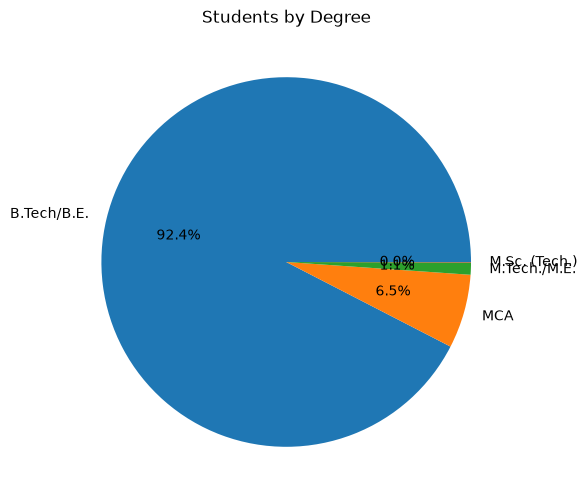

In [50]:
# 2. Pie chart : split of students by Degree

df['Degree'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6),
                                  title='Students by Degree', ylabel='');

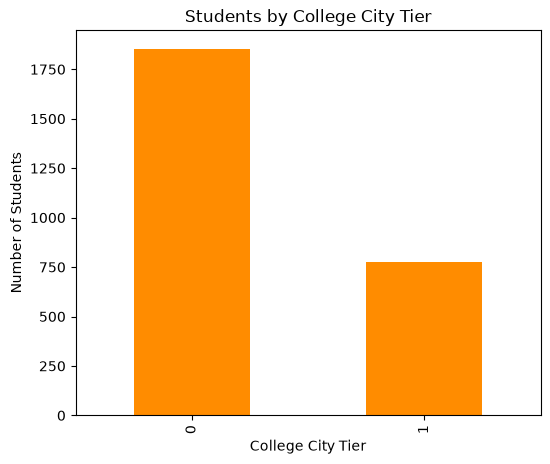

In [51]:
# 3. Bar chart : count of students by College City Tier

df['CollegeCityTier'].value_counts().sort_index().plot(kind='bar', color='darkorange', figsize=(6, 5),
                                                         title='Students by College City Tier',
                                                         xlabel='College City Tier', ylabel='Number of Students');

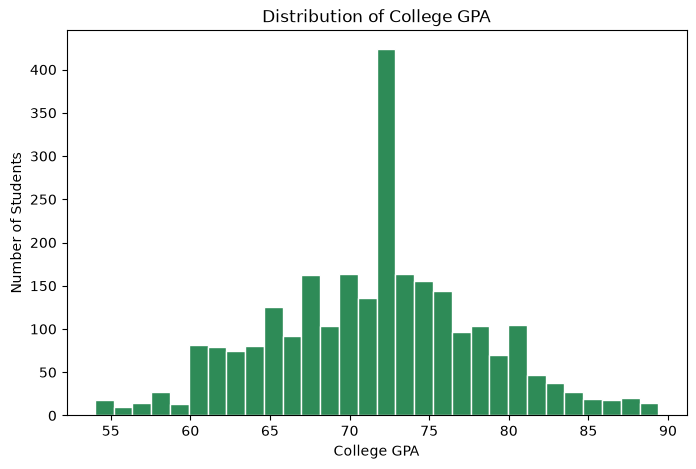

In [52]:
# 4. Histogram : distribution of collegeGPA

df['collegeGPA'].plot(kind='hist', bins=30, color='seagreen', edgecolor='white', figsize=(8, 5),
                       title='Distribution of College GPA', xlabel='College GPA', ylabel='Number of Students');

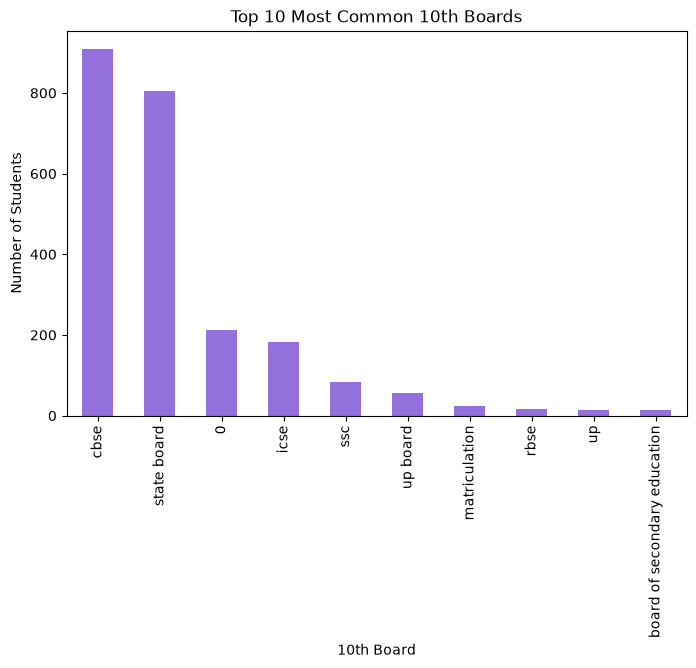

In [53]:
# 5. Bar chart : top 10 most common 10th board

df['10board'].value_counts().head(10).plot(kind='bar', color='mediumpurple', figsize=(8, 5),
                                             title='Top 10 Most Common 10th Boards',
                                             xlabel='10th Board', ylabel='Number of Students');